<font size = 7>**Medical Insurance Prediction using Machine Learning**</font>

# **Project description**

This project is about medical insurance price prediction using machine learning.
Kaggle Medical Insurance Dataset was used. Data contain demographic and lifestyle-related features such as age, sex, BMI, number of children, smoking status, and region, with the target variable being the insurance charges.


You can find data and more description here: https://www.kaggle.com/code/sunilthite/medical-insurance-price-prediction-ml

In [ ]:
# data manipulation
import pandas as pd
import math
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# model selection and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    explained_variance_score
)

# **EDA**

## **Basic information and statistics**

In [ ]:
df = pd.read_csv('insurance.csv')

# display the first 5 rows
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
# display dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None


We have 3 categorical data (sex, smoker and region) that have to be changed later. The rest (age, bmi, children and charges) are numeric data

In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# summary statistics for numerical features
print(df.describe())

               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577.779500
max      64.000000    53.130000     5.000000  63770.428010


The **age column** ranges from 18 to 64 years with a mean of approximately 39 years and a standard deviation of about 14, indicating that age is fairly spread out, centering around late 30s to early 40s.

The **bmi** values range from 15.96 to 53.13, with a mean of approximately 30.7 and a standard deviation of 6.1. This suggests that most individuals are overweight or obese (as BMI > 25), and there is a wide variation in BMI values across the dataset. The 25th percentile is around 26.2 and the 75th percentile is about 34.77, further confirming this trend.

The **children** column shows that the average number of children per individual is about 1.1, with values ranging from 0 to 5. Most individuals have between 0 and 2 children, as indicated by the median of 1 and the 75th percentile value of 2.

The **charges** column, which represents the target variable (insurance cost), has a mean of approximately 13,261 and a standard deviation of over 12,000. The minimum charge is around 1,122, while the maximum reaches over 63,000. This wide range and the fact that the mean is significantly higher than the median (about 9,333) suggest that the distribution of charges is right-skewed, meaning a few individuals incur very high costs. The 25th percentile sits around 4,688 and the 75th percentile at 16,577, reinforcing the presence of skewness and outliers.

## **Graphs of the variables**

### **Overview**

In [ ]:
def plot_histograms_grid(df):
    """
    Plots histograms for all numeric columns in a pandas DataFrame using a grid layout.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the numeric data to plot.
    Returns:
        None. Displays the histograms using matplotlib.
    """
    # all the columns with numeric data
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

    plt.figure(figsize=(2 * 5, 2 * 4)) # size

    for idx, column in enumerate(numeric_columns, 1):
        plt.subplot(2, 2, idx)
        sns.histplot(df[column], kde=False, bins=30, color='steelblue')
        plt.title(f'{column}')
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

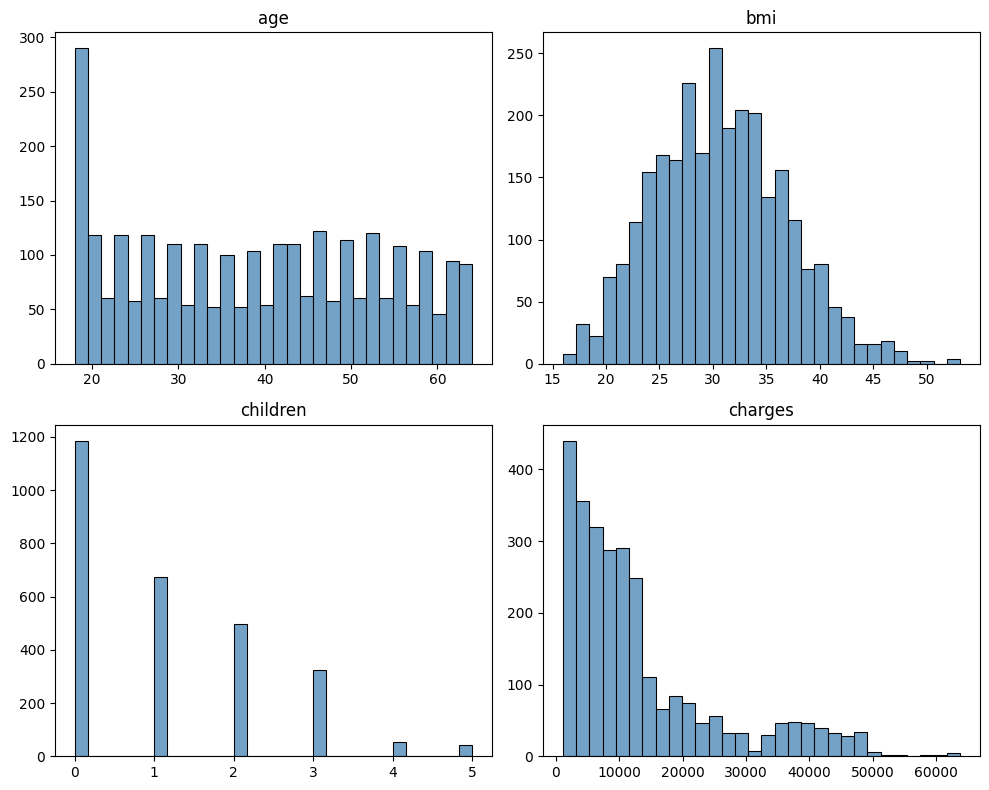

In [ ]:
plot_histograms_grid(df)

**Age** is fairly evenly distributed among adults, with a noticeable spike at 18, possibly due to data collection or insurance policy eligibility.

**BMI** follows an approximately normal distribution, centered around 30, with a slight right skew. This indicates that most individuals fall into the overweight range, with a few outliers on the higher end.

**Children** is a discrete variable showing a strong imbalance — the majority of individuals have 0 to 2 children, with significantly fewer having 3 or more. This suggests it behaves more like a categorical feature.

**Charges** is heavily right-skewed, indicating that while most people incur moderate costs, a small group is responsible for very high expenses.

In [ ]:
def plot_categorical_distributions(df):
    """
    Plots bar plots for all categorical columns in a pandas DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing categorical data to visualize.
    Returns:
        None. Displays the count plots using matplotlib.
    """
    categorical_columns = df.select_dtypes(include='object').columns
    plt.figure(figsize=(2 * 6, 2 * 5))

    for idx, column in enumerate(categorical_columns, 1):
        plt.subplot(2, 2, idx)
        sns.countplot(x=column, data=df, palette='pastel')
        plt.title(f'Distribution of {column}')
        plt.xlabel('')
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

<ipython-input-210-27ff13140641>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df, palette='pastel')
<ipython-input-210-27ff13140641>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df, palette='pastel')
<ipython-input-210-27ff13140641>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df, palette='pastel')


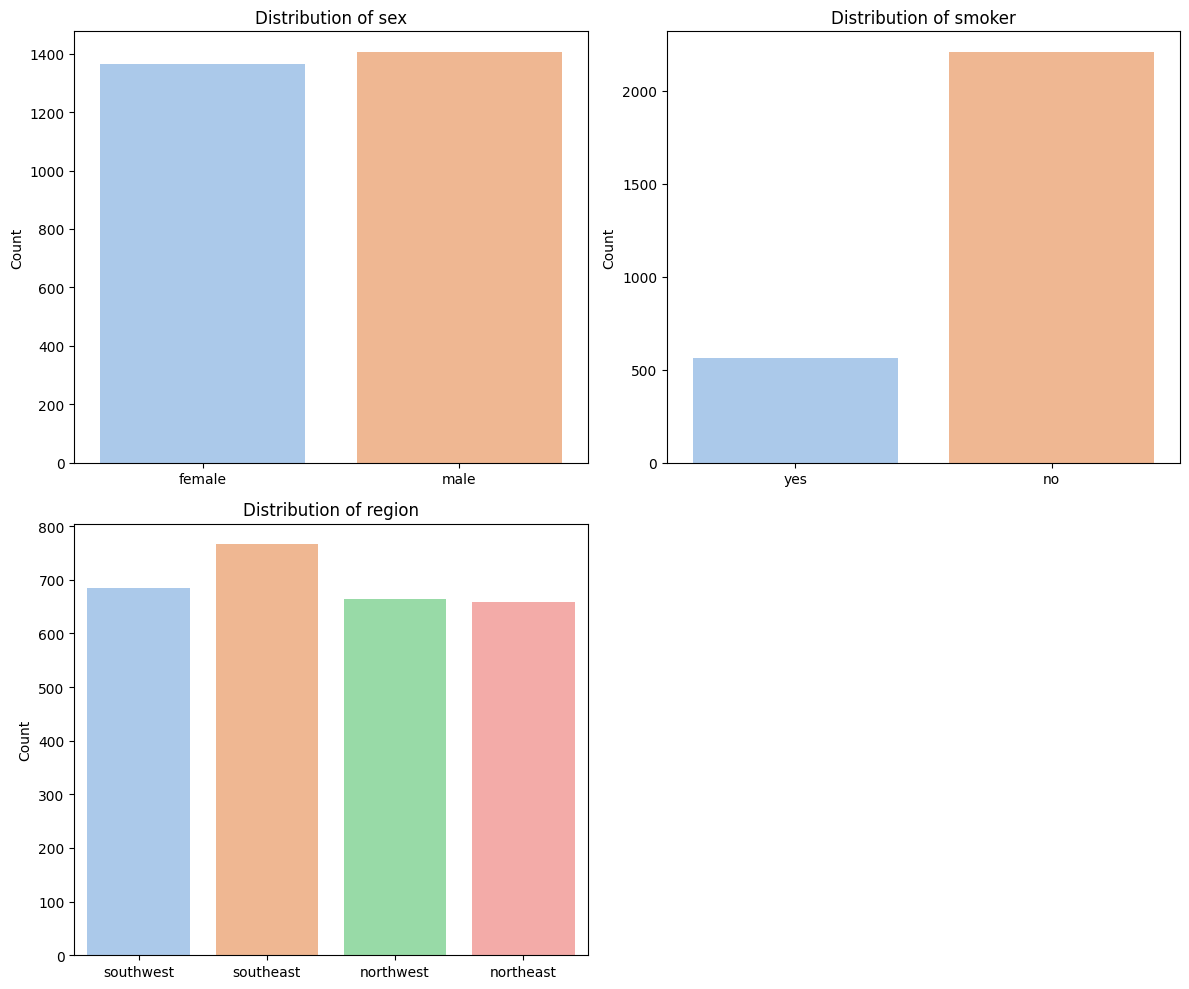

In [ ]:
plot_categorical_distributions(df)

**Sex** is evenly distributed between males and females in the dataset. This balance is beneficial for avoiding gender bias in model predictions.

**Smoker** status is highly imbalanced — a significant majority of individuals are non-smokers, with smokers comprising a much smaller portion.

**Region** shows a fairly balanced distribution across the four geographical areas: southeast, southwest, northwest, and northeast. The southeast has a slightly higher count, but no region is drastically underrepresented.

### **Age**

In [ ]:
def age_distribution(df):
    """
    Display a boxplot of the 'age' column to show its distribution and a
    scatterplot of 'age' vs. 'charges' to visualize their relationship.
    Parameters:
        df (pandas.DataFrame): DataFrame containing 'age' and 'charges' columns.
    Returns:
        None. Shows plots using matplotlib.
    """
    plt.figure(figsize=(12, 5))

    # boxplot of age
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df['age'], color='skyblue')
    plt.title('Age Distribution (Boxplot)')
    plt.xlabel('Age')

    # scatterplot of age vs charges
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='age', y='charges', data=df, color='salmon', alpha=0.6)
    plt.title('Age vs Charges (Scatterplot)')
    plt.xlabel('Age')
    plt.ylabel('Charges')

    plt.tight_layout()
    plt.show()


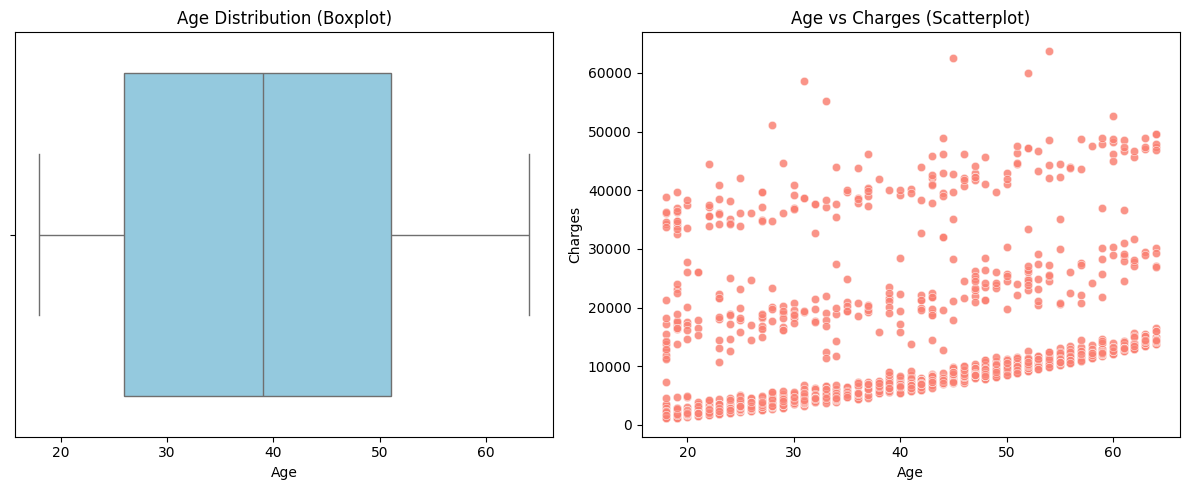

In [ ]:
age_distribution(df)


The boxplot illustrates that there is no outliers in age. The scatterplot of age versus insurance charges reveals a clear positive correlation between age and medical expenses. As age increases, charges generally tend to rise. Additionally, distinct horizontal clusters are noticeable in the plot, which suggests that other categorical variables, such as smoking status or BMI, interact with age and influence the cost. This pattern implies that while age is a strong predictor, interactions with other variables are likely important and should be considered during modeling.

### **BMI**

In [ ]:
def bmi_distribution(df):
    """
    Displays a boxplot of the 'bmi' column to show its distribution and a
    scatterplot of 'bmi' vs. 'charges' to visualize their relationship.
    Parameters:
        df (pandas.DataFrame): DataFrame containing 'bmi' and 'charges' columns.
    Returns:
        None. Shows plots using matplotlib.
    """
    plt.figure(figsize=(12, 5))

    # boxplot of BMI
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df['bmi'], color='lightgreen')
    plt.title('BMI Distribution (Boxplot)')
    plt.xlabel('BMI')

    # scatterplot of BMI vs. Charges
    plt.subplot(1, 2, 2)
    sns.scatterplot(x='bmi', y='charges', data=df, color='darkorange', alpha=0.6)
    plt.title('BMI vs Charges (Scatterplot)')
    plt.xlabel('BMI')
    plt.ylabel('Charges')

    plt.tight_layout()
    plt.show()


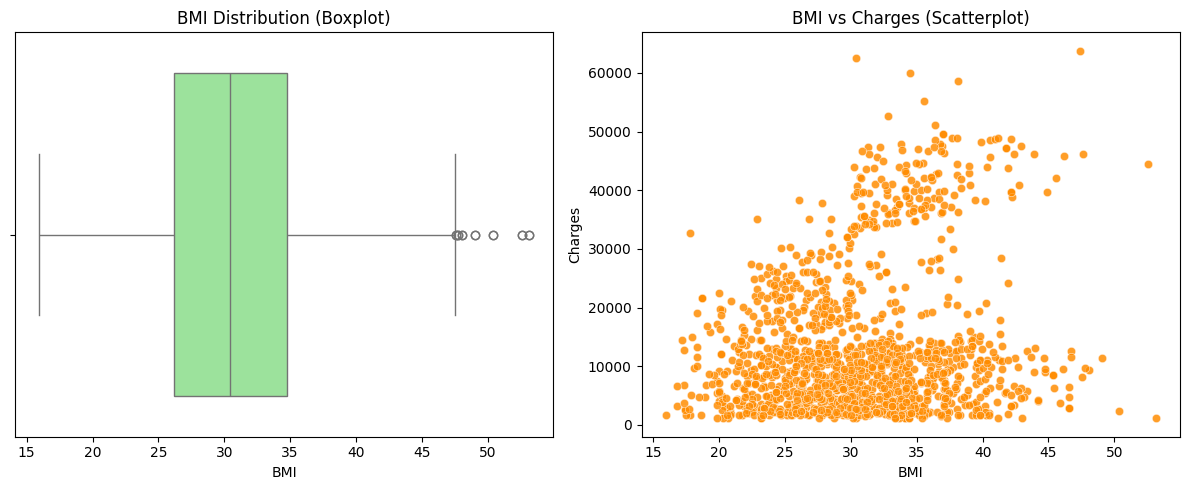

In [ ]:
bmi_distribution(df)


There are several outliers above 45, indicating a small group of individuals with extremely high BMI values. These outliers could potentially affect model performance. The scatterplot of BMI vs. Charges indicates a positive but weak relationship between BMI and insurance charges. While charges tend to rise slightly with higher BMI, the correlation is not very strong or consistent. However, some clusters of higher charges at elevated BMI levels suggest that BMI may interact with other factors (like smoking or age) to influence costs more significantly.

### **Children**

In [ ]:
def children_distribution(df):
    """
    Displays a boxplot of the 'children' column to show its distribution and a
    boxplot of 'children' vs. 'charges' to visualize how charges vary by number of children.
    Parameters:
        df (pandas.DataFrame): DataFrame containing 'children' and 'charges' columns.
    Returns:
        None. Shows plots using matplotlib.
    """
    plt.figure(figsize=(12, 5))

    # boxplot of children
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df['children'], color='lightblue')
    plt.title('Children Count Distribution (Boxplot)')
    plt.xlabel('Number of Children')

    # boxplot of charges by number of children
    plt.subplot(1, 2, 2)
    sns.boxplot(x='children', y='charges', data=df, palette='pastel')
    plt.title('Charges by Number of Children (Boxplot)')
    plt.xlabel('Number of Children')
    plt.ylabel('Charges')

    plt.tight_layout()
    plt.show()


<ipython-input-216-7fc11750c12b>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='children', y='charges', data=df, palette='pastel')


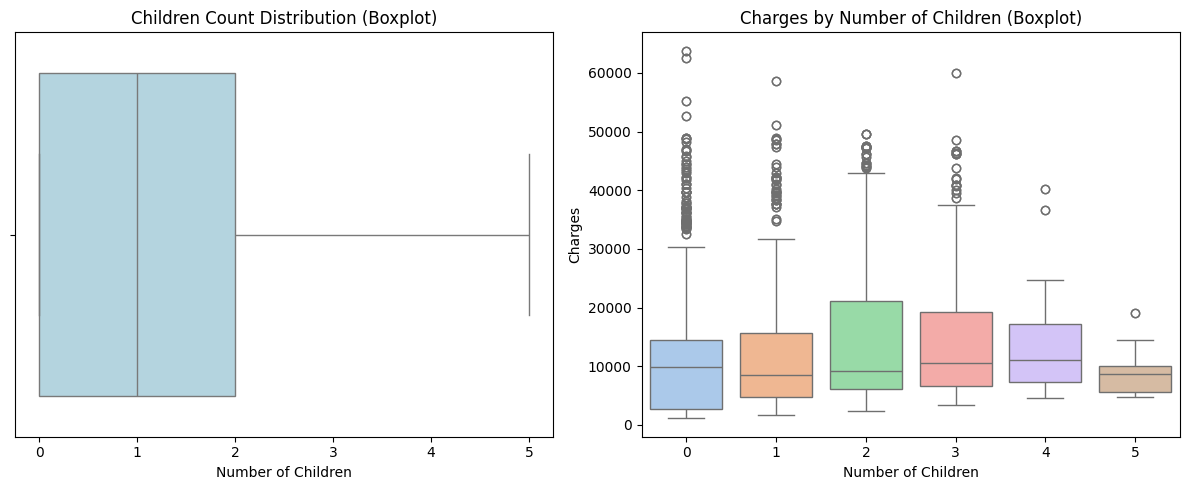

In [ ]:
children_distribution(df)


The left boxplot displays the distribution of the number of children per individual. Most individuals have 0 to 2 children, while larger family sizes (3 to 5 children) are less common.
The right boxplot compares insurance charges by number of children. Overall, there is no strong trend or clear increase in charges as the number of children increases. Charges are fairly consistent across categories, though there is some variation and a presence of outliers in each group. Notably, those with 2 or 3 children show slightly wider spread in charges, possibly influenced by other variables

### **Categorical variables**

In [ ]:
def categorical_boxplots(df, categorical_vars, target='charges'):
    """
    Plots side-by-side boxplots of multiple categorical variables against a numeric target.
    Parameters:
        df (pandas.DataFrame): DataFrame containing the data.
        categorical_vars (list): List of categorical column names to plot.
        target (str): Numeric target column name to compare against (default: 'charges').
    Returns:
        None. Displays plots using matplotlib.
    """
    plt.figure(figsize=(3 * 6, 1 * 5))

    for i, cat in enumerate(categorical_vars, 1):
        plt.subplot(1, 3, i)
        sns.boxplot(x=cat, y=target, data=df, palette='pastel')
        plt.title(f'{target.capitalize()} by {cat.capitalize()}')
        plt.xlabel(cat.capitalize())
        plt.ylabel(target.capitalize())

    plt.tight_layout()
    plt.show()


<ipython-input-218-45ee39f8c0b8>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y=target, data=df, palette='pastel')
<ipython-input-218-45ee39f8c0b8>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y=target, data=df, palette='pastel')
<ipython-input-218-45ee39f8c0b8>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y=target, data=df, palette='pastel')


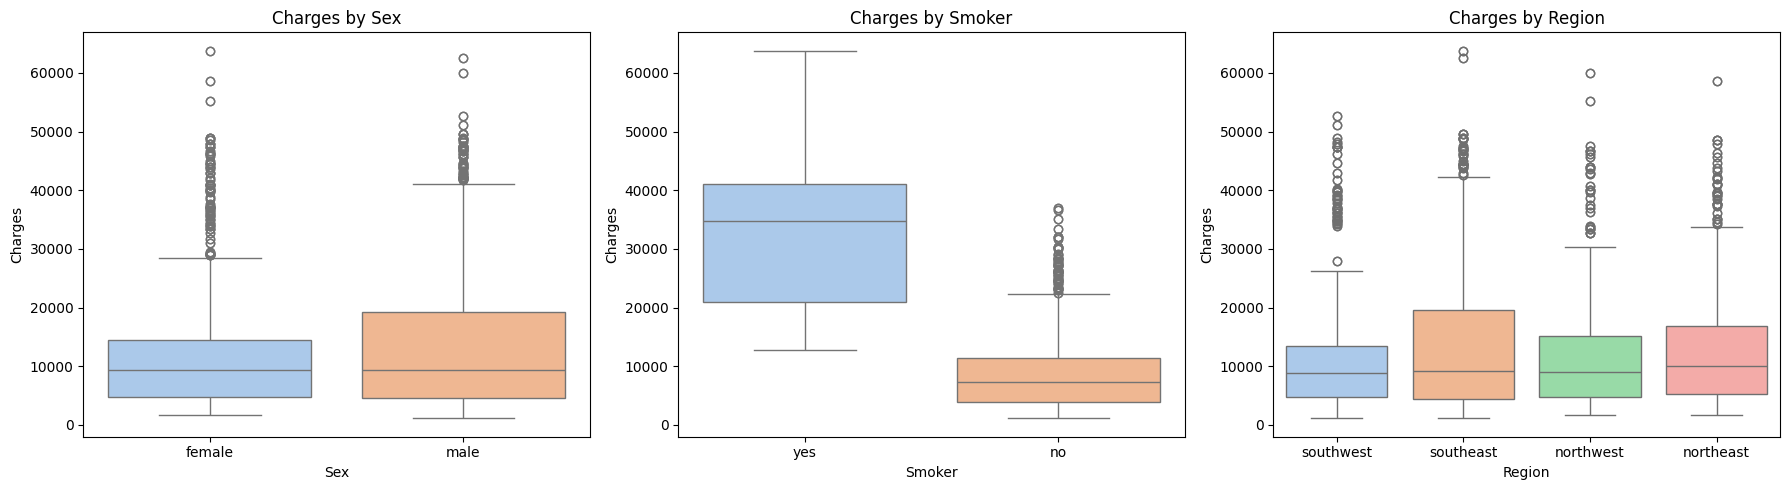

In [ ]:
categorical_boxplots(df, categorical_vars=['sex', 'smoker', 'region'])


The distribution of charges for **males and females** appears quite similar. While there are numerous high-value outliers in both groups, the median charge is only slightly higher for males, indicating that sex likely does not have a major influence on the cost of insurance. The spread and central tendency of the charges are relatively consistent between the two sexes.

In contrast, **smoker** status shows a stark difference in charges. Smokers have a significantly higher median charge compared to non-smokers, and the spread of their charges is much wider, with a large number of extreme outliers. This highlights smoking as a strong factor associated with increased medical expenses. The difference is visually substantial and suggests that smoker status is a key predictor of insurance costs.

When examining charges by **region**, the differences are more subtle. While the Southeast region seems to have slightly higher median charges and more upper outliers, the overall distributions across all four regions—Southwest, Southeast, Northwest, and Northeast—are fairly similar. This implies that geographical location may have some influence on charges, but not nearly as pronounced as smoker status.

Overall, the charts suggest that among the categorical features considered, smoker status has the most significant impact on insurance charges, while sex and region show comparatively weaker relationships.

# **Preprocessing**

## **Handling outliers**

In [ ]:
def remove_bmi_outliers(df):
    """
    Removes only upper outliers from the 'bmi' column based on 1.5×IQR rule.
    Parameters:
        df (pandas.DataFrame): DataFrame containing 'bmi' column.
    Returns:
        pandas.DataFrame: DataFrame with upper outliers removed.
    """
    Q1 = df['bmi'].quantile(0.25)
    Q3 = df['bmi'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    return df[df['bmi'] <= upper_bound]

In [ ]:
remove_bmi_outliers(df)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [ ]:
def plot_bmi_distribution(df):
    """
    Plots the distribution of the 'bmi' column using a histogram and KDE.

    Parameters:
        df (pandas.DataFrame): DataFrame containing the 'bmi' column.
    Returns:
        None. Displays the plot.
    """
    plt.figure(figsize=(8, 5))
    sns.histplot(df['bmi'], bins=30, kde=True, color='skyblue')
    plt.title('Distribution of BMI')
    plt.xlabel('BMI')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


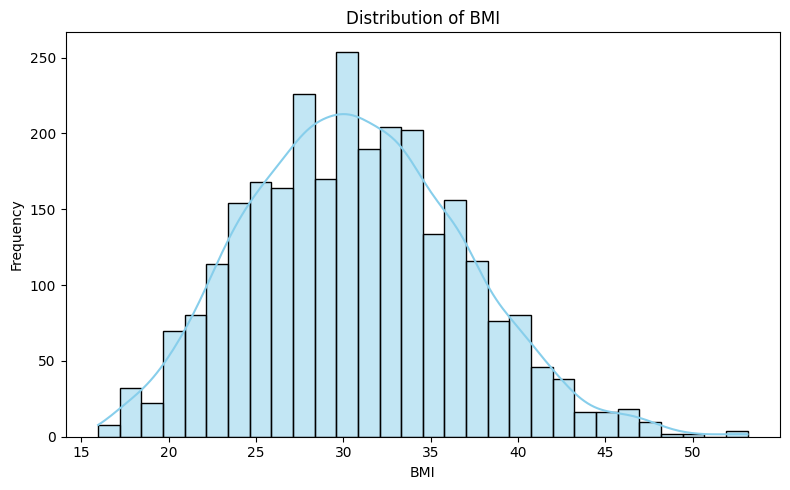

In [ ]:
plot_bmi_distribution(df)

## **Changing categorical data**

In [ ]:
# label encoding
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

In [ ]:
# one hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=False)

In [ ]:
print(df.head())

   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    1  27.900         0       1  16884.92400             False   
1   18    0  33.770         1       0   1725.55230             False   
2   28    0  33.000         3       0   4449.46200             False   
3   33    0  22.705         0       0  21984.47061             False   
4   32    0  28.880         0       0   3866.85520             False   

   region_northwest  region_southeast  region_southwest  
0             False             False              True  
1             False              True             False  
2             False              True             False  
3              True             False             False  
4              True             False             False  


## **Correlation matrix**

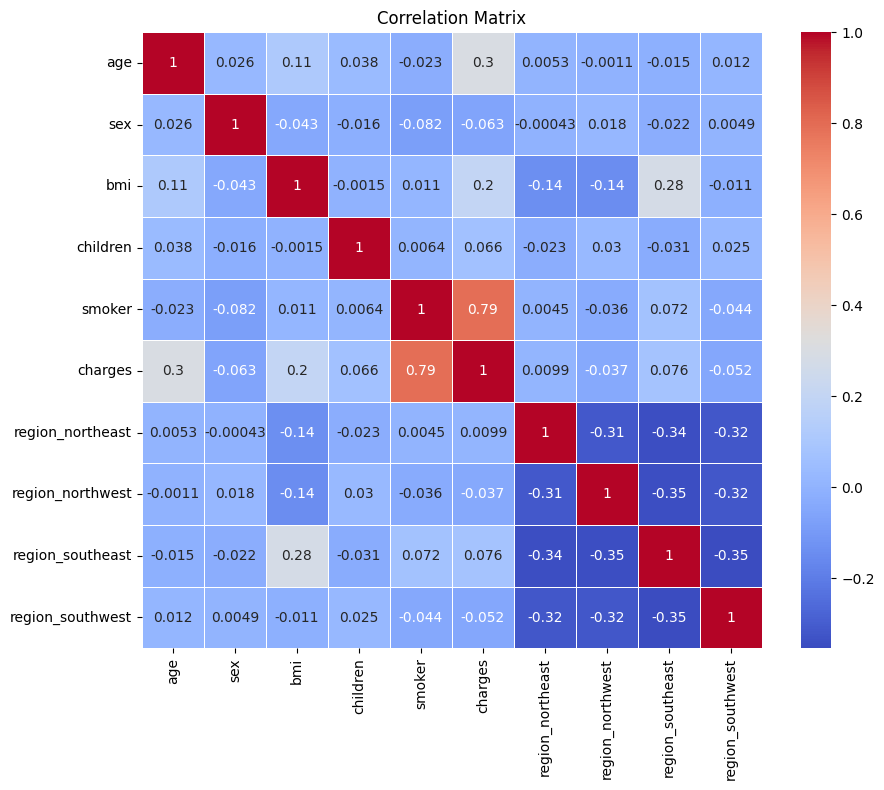

In [ ]:
# compute the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


The correlation matrix helps understand how strongly numerical features are related to each other, particularly to the target variable (charges). A higher correlation (closer to 1 or -1) indicates a stronger linear relationship, which can be very useful in predicting the target.

From the matrix, we observe that **charges** have the strongest positive correlation with the **smoker** variable. This means that being a smoker is strongly associated with higher medical charges, which aligns with real-world expectations.

Next, there is a moderate positive correlation between **charges** and **age**, indicating that older individuals tend to incur higher charges. **BMI** also shows a weaker but noticeable positive correlation, suggesting that higher BMI values may contribute to increased medical costs.

On the other hand, features like **sex**, **region_southwest**, and **region_northwest** have very low or near-zero correlation with charges, implying they may have little linear influence on the target variable. While they could still affect predictions in more complex (non-linear) ways, their direct relationship with charges is minimal.

# **Models**

In [ ]:
# drop the target variable
X = df.drop('charges', axis=1)
y = df['charges']

## **Linear Regression**

LR is not the best choice for this type of data, so it is here just for checking.

In [ ]:
# select only relevant columns for linear regression
features = ['smoker', 'age', 'bmi', 'children', 'region_northeast', 'region_southeast']
X = df[features]
y = df['charges']

# splitting the data, the test size is 20% of the whole set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
# predict and evaluate
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
evs = explained_variance_score(y_test, y_pred)

print("Evaluation on log-transformed charges:")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Evaluation on log-transformed charges:
R²: 0.7391
MAE: 4159.3402
RMSE: 6327.4906


The linear regression model demonstrates solid predictive performance, with an R² score of 0.7391 (73.91%). This suggests a reasonably strong linear relationship between the predictors and the target variable (insurance charges).

The Mean Absolute Error (MAE) of approximately 4159 and the Root Mean Squared Error (RMSE) of about 6327 indicate that, on average, the model’s predictions deviate from the actual charges by around $4,159, with larger errors being somewhat more pronounced (as reflected by the higher RMSE). This reflects the natural variability and skewness present in the original charges data.

Overall, these metrics suggest that the model captures the key patterns in the data and generalizes reasonably well, despite the inherent complexity and spread of the charges distribution

## **Random Forest**

In [ ]:
# splitting the data, the test size is 20% of the whole set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Param grid is used to get the best hyperparameters for the model.

In [ ]:
# define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='r2',
                           verbose=2)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Now we can use this hyperparameters for model training.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    bootstrap=True,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)


rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R² Score: 0.9501
Mean Absolute Error (MAE): 1319.00
Root Mean Squared Error (RMSE): 2767.42


The Random Forest model shows strong performance on the test data. The R² score of 0.9501 indicates that the model explains about 95.01% of the variance in the target variable, which means it captures most of the underlying patterns effectively. The Mean Absolute Error (MAE) of 1,276.65 suggests that, on average, the model’s predictions are off by approximately $1,276.65. This provides a clear idea of the typical size of prediction errors in understandable units. The Root Mean Squared Error (RMSE) is 2,711.85, which is higher than the MAE because it gives more weight to larger errors. This implies that while most prediction errors are moderate, there are some larger deviations present, which is common in real-world datasets. Overall, the model demonstrates solid predictive ability.